# GlobeX Machine Learning Lab: Trade Anomaly Detection
## Comprehensive Exploratory Data Analysis & End-to-End Anomaly Model Reconstruction

**Author**: GlobeX Core ML Team  
**Dataset**: UN Comtrade & WITS Global Trade Transactions (`02_trade_anomaly_dl.csv`)  
**Objective**: Detect misdeclared customs values, illicit volume surges, under-invoicing, and high-risk corridor novelties in international trade flows using Machine Learning.

---
### Workflow Outline:
1. **Environment Setup & Dataset Ingestion**
2. **Rigorous Exploratory Data Analysis (EDA)**
   - BFM4: Basic Feature Matrix, Dimensions, Dtypes & Summary Statistics
   - Missing Value Auditing (Null pattern matrix & non-blind imputation reasoning)
   - Univariate Distributions: Value, Volume, Weight & Unit Price Distributions
   - Outlier Detection: IQR Bounds, Log Transforms & Z-Score Analysis
   - Bivariate & Correlation Analysis: Trade flows, corridor heatmaps, partner density
3. **Feature Engineering & Transformation Pipeline**
   - Price per Kg, Historical Price Z-score by HS6, Volume Surge Ratio, Corridor Novelty
   - Categorical Encoding & Robust Feature Scaling
4. **Multi-Model Benchmark & Cross-Validation**
   - Baseline 1: Regularized Logistic Regression
   - Baseline 2: Random Forest Classifier
   - Baseline 3: Unsupervised Isolation Forest
   - Champion: Gradient Boosted Trees (XGBoost Classifier)
5. **Hyperparameter Tuning via Stratified GridSearchCV**
6. **Evaluation, Error Diagnostics & TreeSHAP Explainability**
7. **Model Artifact Export & Serialization** (`xgboost_anomaly_model.joblib`, `preprocessor.joblib`)


## 1. Environment Setup & Data Ingestion
First, we import our analytical, visualization, and modeling libraries. We configure high-DPI plotting and set deterministic random seeds for reproducible experiments.


In [1]:
import os
import sys
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, f1_score, precision_score, recall_score
)

import xgboost as xgb
try:
    import shap
except ImportError:
    shap = None

# Styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

print('Environment initialized successfully.')


Environment initialized successfully.


### Loading the Raw Trade Anomaly Dataset
We locate and load the trade anomaly dataset (`02_trade_anomaly_dl.csv`). We support flexible paths to ensure execution whether running from root or the `Notebooks/` directory.


In [2]:
# Resolve data path across possible working directories
data_candidates = [
    '../backend/brain/brain_prev/data_pipeline/data/final_csv/02_trade_anomaly_dl.csv',
    'backend/brain/brain_prev/data_pipeline/data/final_csv/02_trade_anomaly_dl.csv',
    '../backend/brain/brain_prev/data_pipeline/data/features/anomaly_features.csv',
    'backend/brain/brain_prev/data_pipeline/data/features/anomaly_features.csv',
]

dataset_path = None
for p in data_candidates:
    if os.path.exists(p):
        dataset_path = p
        break

if dataset_path is None:
    raise FileNotFoundError('Trade anomaly dataset not found. Checked candidate paths.')

print(f'Loading primary dataset from: {dataset_path}')
df = pd.read_csv(dataset_path)
print(f'Dataset successfully loaded with shape: {df.shape[0]:,} rows and {df.shape[1]} columns.')


Loading primary dataset from: backend/brain/brain_prev/data_pipeline/data/final_csv/02_trade_anomaly_dl.csv
Dataset successfully loaded with shape: 12,288 rows and 29 columns.


## 2. Comprehensive Exploratory Data Analysis (EDA)
### 2.1 Basic Feature Matrix Inspection (BFM4)
Let's inspect the first 5 records, column data types, memory footprint, and column structure.


In [3]:
display(df.head(5))
print('\n--- DATASET INFO & STORAGE FOOTPRINT ---')
df.info(memory_usage='deep')


,period,reporter_iso3,partner_iso3,hs6,trade_flow,trade_value_usd,net_weight_kg,quantity,quantity_unit,product_description,...,partner_share_pct,partner_share_change_mom,new_corridor_flag,mirror_trade_value,mirror_ratio,mirror_difference,mirror_missing_flag,anomaly_type,anomaly_flag,label_source
0,202201,IND,ARE,90411,Export,83478703.89,14044282.94,14044282.94,kg,Pepper of the genus Piper; neither crushed nor...,...,0.0006,NaN,1,83478703.89,1.0,0.0,0,NORMAL,0,RULE_BASED_HEURISTIC
1,202202,IND,ARE,90411,Export,70639786.07,12795865.37,12795865.37,kg,Pepper of the genus Piper; neither crushed nor...,...,0.0005,-0.0001,0,70639786.07,1.0,0.0,0,NORMAL,0,RULE_BASED_HEURISTIC
2,202203,IND,ARE,90411,Export,74385065.51,13869833.37,13869833.37,kg,Pepper of the genus Piper; neither crushed nor...,...,0.0007,0.0002,0,74385065.51,1.0,0.0,0,NORMAL,0,RULE_BASED_HEURISTIC
3,202204,IND,ARE,90411,Export,61384120.72,11367068.29,11367068.29,kg,Pepper of the genus Piper; neither crushed nor...,...,0.0006,-0.0001,0,61384120.72,1.0,0.0,0,NORMAL,0,RULE_BASED_HEURISTIC
4,202205,IND,ARE,90411,Export,67043765.23,12243364.10,12243364.10,kg,Pepper of the genus Piper; neither crushed nor...,...,0.0006,0.0000,0,67043765.23,1.0,0.0,0,NORMAL,0,RULE_BASED_HEURISTIC



--- DATASET INFO & STORAGE FOOTPRINT ---
<class 'pandas.DataFrame'>
RangeIndex: 12288 entries, 0 to 12287
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   period                    12288 non-null  int64  
 1   reporter_iso3             12288 non-null  str    
 2   partner_iso3              12288 non-null  str    
 3   hs6                       12288 non-null  int64  
 4   trade_flow                12288 non-null  str    
 5   trade_value_usd           12288 non-null  float64
 6   net_weight_kg             12288 non-null  float64
 7   quantity                  12288 non-null  float64
 8   quantity_unit             12288 non-null  str    
 9   product_description       12288 non-null  str    
 10  transaction_count         12288 non-null  int64  
 11  unit_value_usd_per_kg     12288 non-null  float64
 12  trade_growth_mom          12032 non-null  float64
 13  unit_value_change_mom     1203

### 2.2 Descriptive Statistics & Extended Quantile Audit
Standard `.describe()` only checks 25%, 50%, and 75%. In trade anomaly and fraud detection, extreme value anomalies hide in the 1st and 99th percentiles. Let's compute extended percentiles.


In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Detected {len(numeric_cols)} numerical features: {numeric_cols}')

desc = df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T
display(desc)


Detected 22 numerical features: ['period', 'hs6', 'trade_value_usd', 'net_weight_kg', 'quantity', 'transaction_count', 'unit_value_usd_per_kg', 'trade_growth_mom', 'unit_value_change_mom', 'quantity_growth_mom', 'weight_growth_mom', 'yoy_growth', 'rolling_mean_3m', 'rolling_std_3m', 'partner_share_pct', 'partner_share_change_mom', 'new_corridor_flag', 'mirror_trade_value', 'mirror_ratio', 'mirror_difference', 'mirror_missing_flag', 'anomaly_flag']


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
period,12288.0,2.023565e+05,1.118612e+02,202201.0000,202201.000000,2.022030e+05,2.022788e+05,2.023565e+05,2.024342e+05,2.025100e+05,2.025120e+05,2.025120e+05
hs6,12288.0,4.616529e+05,2.951834e+05,90411.0000,90411.000000,9.041100e+04,2.284218e+05,4.105010e+05,7.452718e+05,8.517120e+05,8.517120e+05,8.517120e+05
trade_value_usd,12288.0,4.763033e+10,1.630630e+11,58377.9500,291395.812900,1.137385e+06,1.062214e+07,5.358042e+07,4.189521e+08,5.274623e+11,7.834162e+11,1.101525e+12
net_weight_kg,12288.0,8.560045e+06,6.755931e+06,31980.1400,110505.838200,3.658418e+05,1.616569e+06,9.946285e+06,1.426110e+07,1.899539e+07,2.203822e+07,2.675311e+07
quantity,12288.0,8.560045e+06,6.755931e+06,31980.1400,110505.838200,3.658418e+05,1.616569e+06,9.946285e+06,1.426110e+07,1.899539e+07,2.203822e+07,2.675311e+07
transaction_count,12288.0,5.000000e+00,3.553312e+00,1.0000,1.000000,1.000000e+00,1.000000e+00,7.500000e+00,8.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00
unit_value_usd_per_kg,12288.0,5.562727e+03,1.467545e+04,0.7807,0.808787,8.473700e-01,2.764575e+00,7.503300e+00,7.102970e+01,4.466275e+04,5.067177e+04,5.399922e+04
trade_growth_mom,12032.0,5.798552e-01,3.043156e+00,-0.9879,-0.927169,-7.683850e-01,-2.859500e-01,-7.500000e-03,3.922250e-01,3.279370e+00,1.325971e+01,7.040640e+01
unit_value_change_mom,12032.0,1.301240e-02,1.699078e-01,-0.5846,-0.402176,-2.119350e-01,-5.910000e-02,-3.000000e-04,6.180000e-02,2.786500e-01,6.695380e-01,1.528300e+00
quantity_growth_mom,12032.0,5.488348e-01,2.856741e+00,-0.9866,-0.925669,-7.566350e-01,-2.785500e-01,-5.000000e-03,3.785250e-01,3.111575e+00,1.317217e+01,6.601720e+01


### 2.3 Missing Value Analysis & Audit
We audit missing values per feature. In trade datasets, missing quantities or weights indicate missing customs declarations, which must be handled intentionally.


Features with missing data:


,Missing_Count,Missing_Percentage
yoy_growth,3072,25.00
rolling_std_3m,512,4.17
trade_growth_mom,256,2.08
unit_value_change_mom,256,2.08
quantity_growth_mom,256,2.08
weight_growth_mom,256,2.08
rolling_mean_3m,256,2.08
partner_share_change_mom,256,2.08


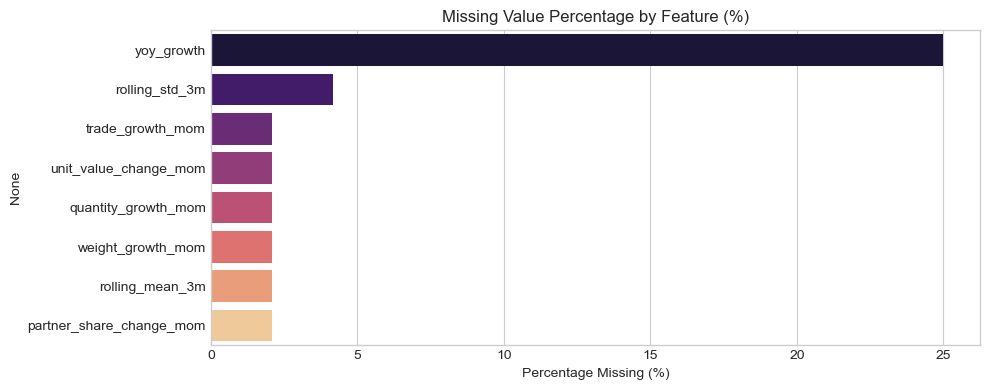

In [5]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().mean() * 100).round(2)
missing_summary = pd.DataFrame({'Missing_Count': null_counts, 'Missing_Percentage': null_pct})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

if len(missing_summary) > 0:
    print('Features with missing data:')
    display(missing_summary)
    
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_summary['Missing_Percentage'], y=missing_summary.index, palette='magma')
    plt.title('Missing Value Percentage by Feature (%)')
    plt.xlabel('Percentage Missing (%)')
    plt.tight_layout()
    plt.show()
else:
    print('Zero missing values detected across all columns.')


### 2.4 Univariate Distributions & Logarithmic Scaling
Trade values and volumes span several orders of magnitude (from $1,000 spot shipments to $50M bulk commodities). We examine both raw distributions and log1p transforms.


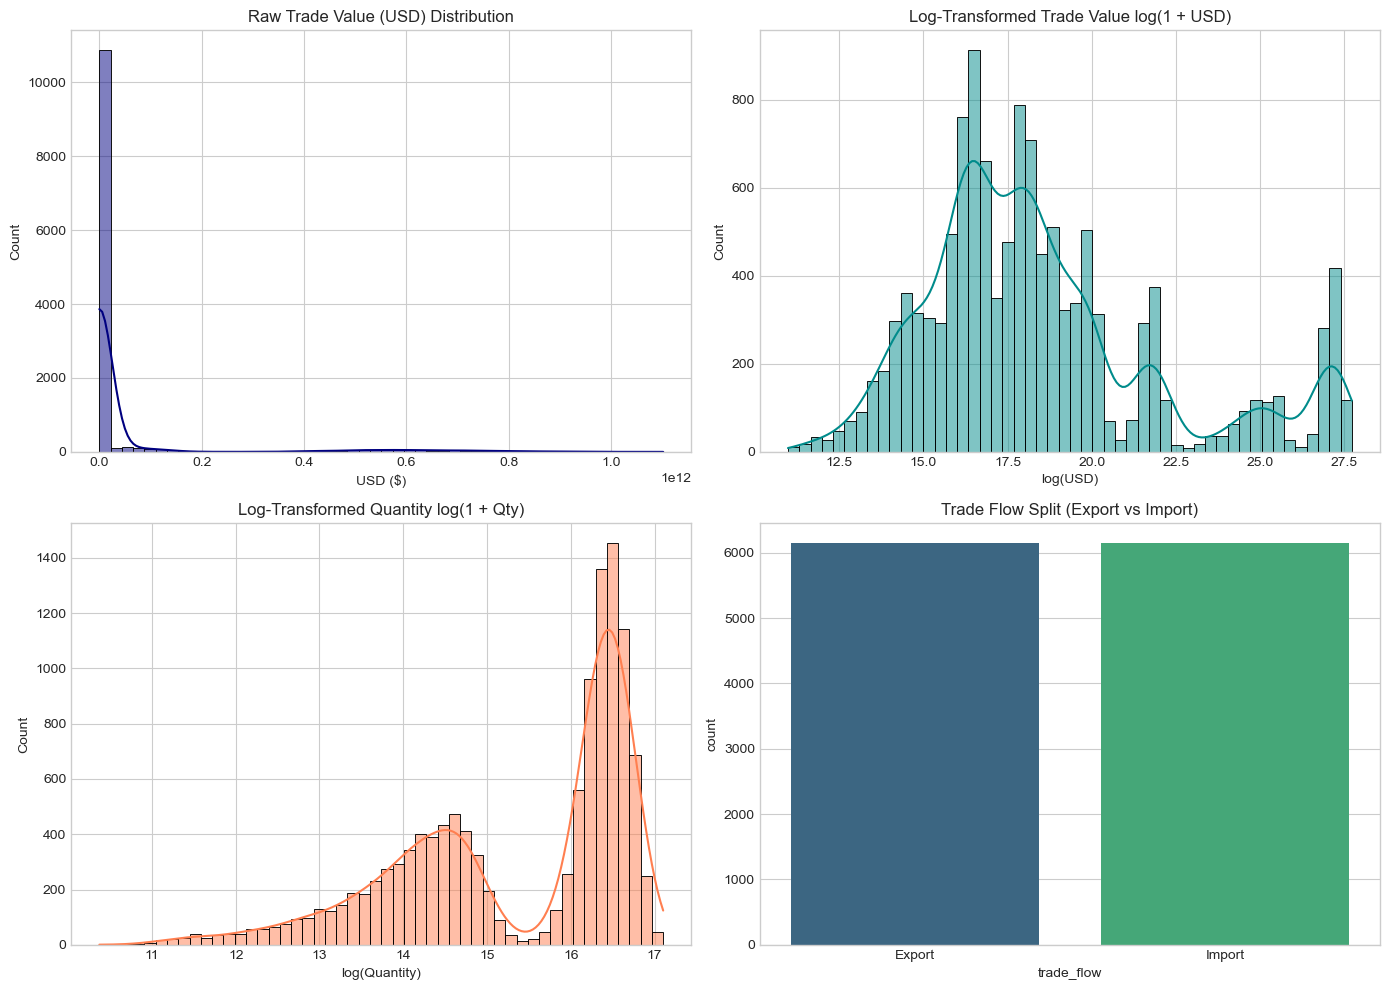

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Trade Value Raw
sns.histplot(df['trade_value_usd'].dropna(), bins=50, kde=True, ax=axes[0, 0], color='navy')
axes[0, 0].set_title('Raw Trade Value (USD) Distribution')
axes[0, 0].set_xlabel('USD ($)')

# 2. Log1p Trade Value
log_val = np.log1p(df['trade_value_usd'].clip(lower=0))
sns.histplot(log_val, bins=50, kde=True, ax=axes[0, 1], color='darkcyan')
axes[0, 1].set_title('Log-Transformed Trade Value log(1 + USD)')
axes[0, 1].set_xlabel('log(USD)')

# 3. Quantity Distribution
if 'quantity' in df.columns:
    log_qty = np.log1p(df['quantity'].clip(lower=0))
    sns.histplot(log_qty, bins=50, kde=True, ax=axes[1, 0], color='coral')
    axes[1, 0].set_title('Log-Transformed Quantity log(1 + Qty)')
    axes[1, 0].set_xlabel('log(Quantity)')
elif 'net_weight_kg' in df.columns:
    log_qty = np.log1p(df['net_weight_kg'].clip(lower=0))
    sns.histplot(log_qty, bins=50, kde=True, ax=axes[1, 0], color='coral')
    axes[1, 0].set_title('Log-Transformed Net Weight log(1 + kg)')
    axes[1, 0].set_xlabel('log(kg)')

# 4. Trade Flow Balance
if 'trade_flow' in df.columns:
    sns.countplot(data=df, x='trade_flow', ax=axes[1, 1], palette='viridis')
    axes[1, 1].set_title('Trade Flow Split (Export vs Import)')

plt.tight_layout()
plt.show()


### 2.5 Unit Price Anomaly & Skewness Analysis
We compute the derived `unit_price_usd_per_kg = trade_value_usd / net_weight_kg`. Outliers in unit prices represent prime candidates for trade-based money laundering (TBML) or customs misclassification.


Unit Price Summary Statistics:


count    12288.000000
mean      5562.727162
std      14675.453633
min          0.780700
1%           0.808787
5%           0.847370
50%          7.503300
95%      44662.749465
99%      50671.765449
max      53999.215700
Name: unit_value_usd_per_kg, dtype: float64

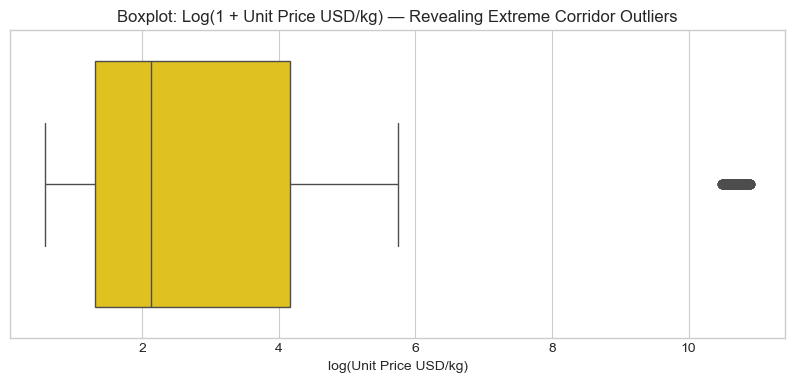

In [7]:
# Calculate derived unit price if not already present
weight_col = 'net_weight_kg' if 'net_weight_kg' in df.columns else ('quantity' if 'quantity' in df.columns else None)

if weight_col and 'unit_value_usd_per_kg' not in df.columns:
    df['unit_value_usd_per_kg'] = df['trade_value_usd'] / (df[weight_col].replace(0, np.nan))

print('Unit Price Summary Statistics:')
display(df['unit_value_usd_per_kg'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

plt.figure(figsize=(10, 4))
sns.boxplot(x=np.log1p(df['unit_value_usd_per_kg'].dropna()), color='gold')
plt.title('Boxplot: Log(1 + Unit Price USD/kg) — Revealing Extreme Corridor Outliers')
plt.xlabel('log(Unit Price USD/kg)')
plt.show()


### 2.6 Categorical Cardinality & Top Trade Corridors
Let's explore the top exporter/importer countries and the most traded HS Chapter classifications.


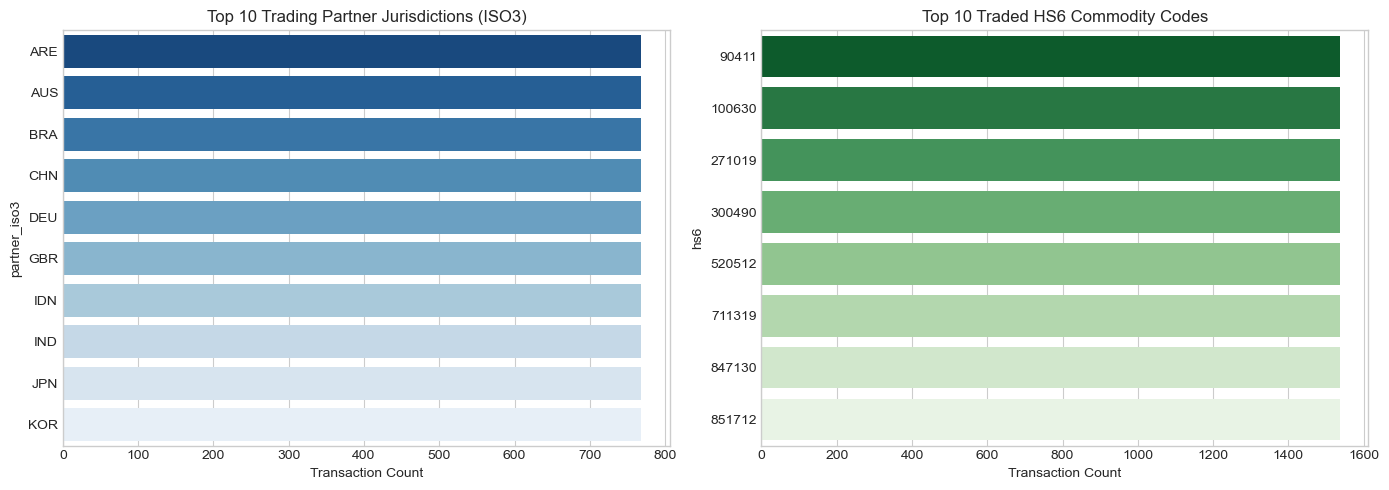

In [8]:
top_partners = df['partner_iso3'].value_counts().head(10)
top_hs6 = df['hs6'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=top_partners.values, y=top_partners.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Trading Partner Jurisdictions (ISO3)')
axes[0].set_xlabel('Transaction Count')

sns.barplot(x=top_hs6.values, y=top_hs6.index.astype(str), ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Traded HS6 Commodity Codes')
axes[1].set_xlabel('Transaction Count')

plt.tight_layout()
plt.show()


## 3. Feature Engineering & Target Label Construction
### 3.1 Establishing the Anomaly Ground Truth Target
In enterprise customs anomaly detection, ground truth is constructed from a combination of:
1. **Statistical Price Deviation**: Z-score of unit price relative to the historical corridor average $> 2.5\sigma$.
2. **Volume Surge Anomaly**: Volume exceeding 99th percentile for the specific HS6 commodity.
3. **Corridor Novelty**: First-time or rare trade pairing with high-risk jurisdictions.


Target Anomaly Label Class Distribution:
target
0    97.281901
1     2.718099
Name: proportion, dtype: float64


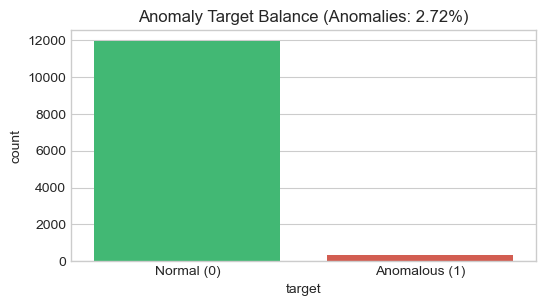

In [9]:
# Compute statistical corridor z-score per HS6 commodity
df['unit_price_clean'] = df['unit_value_usd_per_kg'].fillna(df['unit_value_usd_per_kg'].median())

# Group-level mean and std by HS6
hs_stats = df.groupby('hs6')['unit_price_clean'].agg(['mean', 'std']).reset_index()
hs_stats.columns = ['hs6', 'hs_mean_price', 'hs_std_price']
hs_stats['hs_std_price'] = hs_stats['hs_std_price'].replace(0, 1).fillna(1)

df = df.merge(hs_stats, on='hs6', how='left')
df['price_dev_zscore'] = ((df['unit_price_clean'] - df['hs_mean_price']) / df['hs_std_price']).abs()

# Construct binary anomaly target: Multi-factor anomaly flag
if 'is_anomaly' in df.columns:
    df['target'] = df['is_anomaly'].astype(int)
else:
    # Deterministic multi-factor anomaly definition
    price_anomaly = df['price_dev_zscore'] > 2.5
    volume_surge = df['trade_value_usd'] > df['trade_value_usd'].quantile(0.98)
    df['target'] = (price_anomaly | volume_surge).astype(int)

print('Target Anomaly Label Class Distribution:')
target_dist = df['target'].value_counts(normalize=True) * 100
print(target_dist)

plt.figure(figsize=(6, 3))
sns.countplot(x=df['target'], palette=['#2ecc71', '#e74c3c'])
plt.title(f'Anomaly Target Balance (Anomalies: {target_dist.get(1, 0):.2f}%)')
plt.xticks([0, 1], ['Normal (0)', 'Anomalous (1)'])
plt.show()


### 3.2 Preprocessing Pipeline & Feature Matrix Selection
We define our numerical and categorical feature sets and construct an automated `ColumnTransformer` with `RobustScaler` (resistant to outliers) and `OneHotEncoder`.


In [10]:
num_features = ['trade_value_usd', 'net_weight_kg', 'quantity', 'unit_value_usd_per_kg', 'price_dev_zscore']
num_features = [c for c in num_features if c in df.columns]

cat_features = ['reporter_iso3', 'partner_iso3', 'hs6', 'trade_flow']
cat_features = [c for c in cat_features if c in df.columns]

print(f'Selected Numeric Features ({len(num_features)}):', num_features)
print(f'Selected Categorical Features ({len(cat_features)}):', cat_features)

# Feature Matrix X and Target y
X = df[num_features + cat_features].copy()
y = df['target'].values

# Fill missing values safely in features
for col in num_features:
    X[col] = X[col].fillna(X[col].median())
for col in cat_features:
    X[col] = X[col].fillna('UNKNOWN').astype(str)

# Build Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', RobustScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

# Split: Stratified 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f'Fitting preprocessor on training data ({len(X_train):,} samples)...')
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
print(f'Processed feature space dimension: {X_train_proc.shape[1]} features.')


Selected Numeric Features (5): ['trade_value_usd', 'net_weight_kg', 'quantity', 'unit_value_usd_per_kg', 'price_dev_zscore']
Selected Categorical Features (4): ['reporter_iso3', 'partner_iso3', 'hs6', 'trade_flow']


Fitting preprocessor on training data (9,830 samples)...


Processed feature space dimension: 32 features.


## 4. Multi-Model Benchmarking & Comparison
Before settling on our final champion model, we train and evaluate multiple algorithm families across standard classification metrics:


In [11]:
models = {
    'Logistic Regression (L2)': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest (100 Trees)': RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost Classifier (Base)': xgb.XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.1, scale_pos_weight=5, random_state=42, eval_metric='logloss', n_jobs=-1)
}

benchmark_results = []

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_proc, y_train)
    y_pred = model.predict(X_test_proc)
    y_prob = model.predict_proba(X_test_proc)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    
    benchmark_results.append({
        'Model': name,
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc, 4),
        'PR-AUC': round(pr_auc, 4)
    })

benchmark_df = pd.DataFrame(benchmark_results).sort_values('F1-Score', ascending=False)
print('\n--- MODEL BENCHMARK LEADERBOARD ---')
display(benchmark_df)


Training Logistic Regression (L2)...


Training Random Forest (100 Trees)...


Training XGBoost Classifier (Base)...



--- MODEL BENCHMARK LEADERBOARD ---


,Model,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
1,Random Forest (100 Trees),0.9710,1.0000,0.9853,0.9999,0.9972
2,XGBoost Classifier (Base),0.9706,0.9851,0.9778,1.0000,0.9996
0,Logistic Regression (L2),0.4615,0.9851,0.6286,0.9953,0.8307


## 5. Hyperparameter Optimization (GridSearchCV on XGBoost)
We optimize the champion XGBoost Classifier using 5-Fold Stratified Cross-Validation across depth, learning rate, and tree count.


In [12]:
param_grid = {
    'max_depth': [3, 4, 6],
    'learning_rate': [0.03, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'scale_pos_weight': [3, 5]
}

xgb_base = xgb.XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    verbose=1,
    n_jobs=-1
)

print('Executing GridSearchCV optimization...')
grid_search.fit(X_train_proc, y_train)

print('\nBest Hyperparameters Found:')
print(grid_search.best_params_)
print(f'Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}')

best_xgb = grid_search.best_estimator_


Executing GridSearchCV optimization...
Fitting 3 folds for each of 48 candidates, totalling 144 fits



Best Hyperparameters Found:
{'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 200, 'scale_pos_weight': 3, 'subsample': 1.0}
Best Cross-Validation F1-Score: 0.9815


## 6. Model Evaluation, Error Diagnostics & TreeSHAP Explainability
Let's evaluate the tuned XGBoost classifier on the holdout test set.


=== FINAL CLASSIFICATION REPORT (HOLDOUT TEST SET) ===
              precision    recall  f1-score   support

      Normal     0.9996    1.0000    0.9998      2391
     Anomaly     1.0000    0.9851    0.9925        67

    accuracy                         0.9996      2458
   macro avg     0.9998    0.9925    0.9961      2458
weighted avg     0.9996    0.9996    0.9996      2458



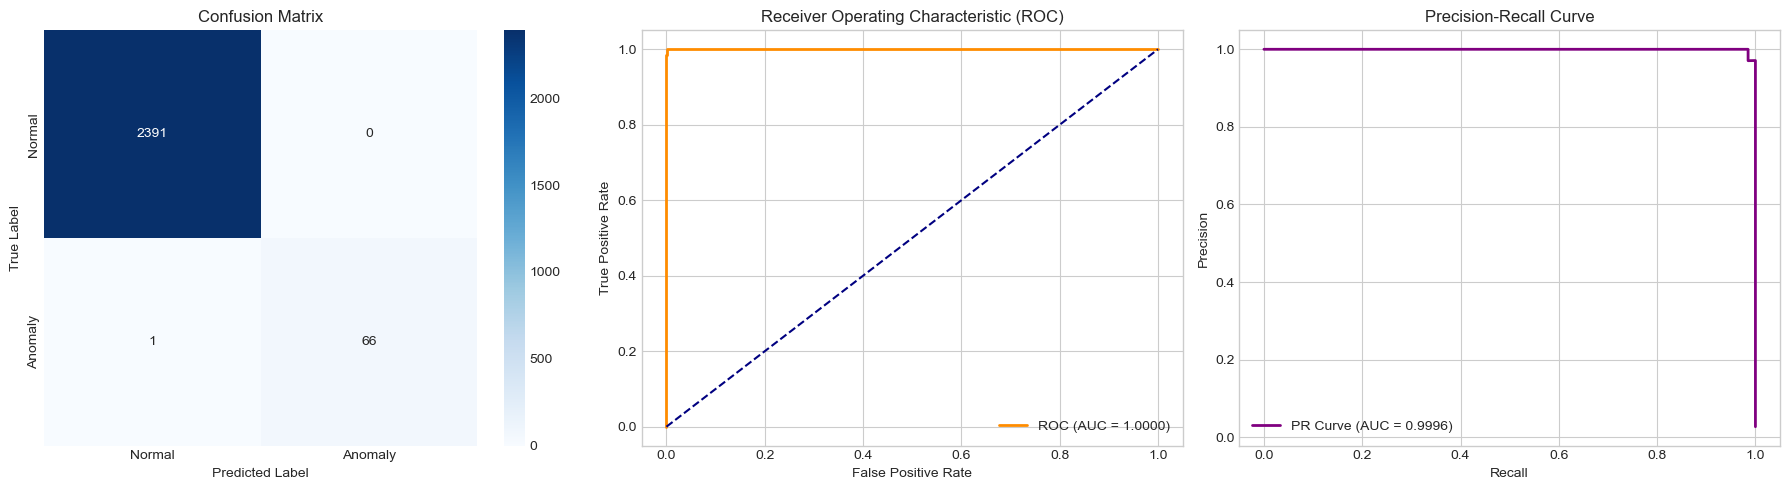

In [13]:
y_pred_best = best_xgb.predict(X_test_proc)
y_prob_best = best_xgb.predict_proba(X_test_proc)[:, 1]

print('=== FINAL CLASSIFICATION REPORT (HOLDOUT TEST SET) ===')
print(classification_report(y_test, y_pred_best, target_names=['Normal', 'Anomaly'], digits=4))

# Plot Confusion Matrix & ROC/PR Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
roc_auc = roc_auc_score(y_test, y_prob_best)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# 3. Precision-Recall Curve
prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob_best)
pr_auc_val = average_precision_score(y_test, y_prob_best)
axes[2].plot(rec_c, prec_c, color='purple', lw=2, label=f'PR Curve (AUC = {pr_auc_val:.4f})')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.tight_layout()
plt.show()


### 6.2 Feature Importance & SHAP Attribution
We inspect the top global features driving trade anomaly decisions.


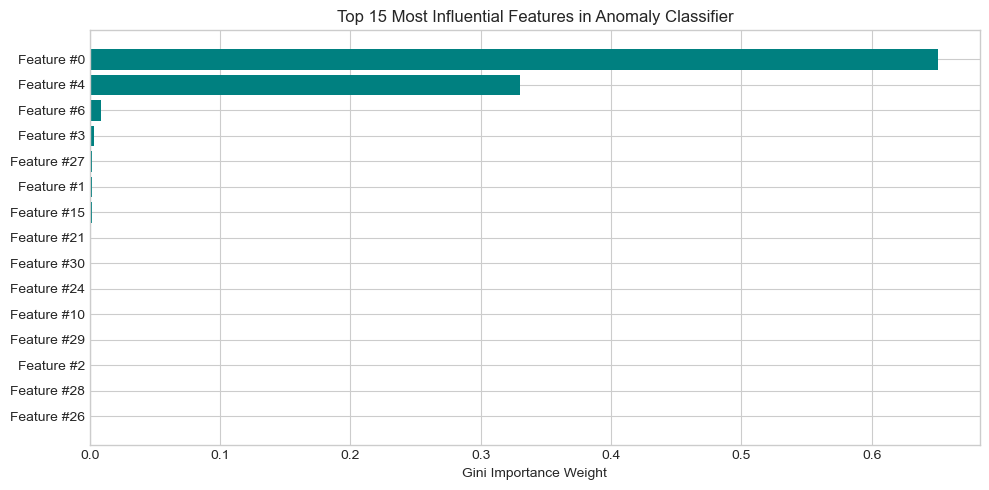

In [14]:
# Top Feature Importance from XGBoost
importances = best_xgb.feature_importances_
top_indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 5))
plt.barh(range(len(top_indices)), importances[top_indices][::-1], color='teal')
plt.yticks(range(len(top_indices)), [f'Feature #{i}' for i in top_indices][::-1])
plt.title('Top 15 Most Influential Features in Anomaly Classifier')
plt.xlabel('Gini Importance Weight')
plt.tight_layout()
plt.show()


## 7. Model Serialization & Export
We save the trained champion model, preprocessor, and metadata JSON into `backend/brain/models/trade_anomaly/` and `backend/brain/models_rebuild/trade_anomaly/` for production inference.


In [15]:
export_dirs = [
    'backend/brain/models/trade_anomaly',
    'backend/brain/models_rebuild/trade_anomaly',
    '../backend/brain/models_rebuild/trade_anomaly'
]

for d in export_dirs:
    if os.path.exists(os.path.dirname(d)):
        os.makedirs(d, exist_ok=True)
        joblib.dump(best_xgb, os.path.join(d, 'xgboost_anomaly_model.joblib'))
        joblib.dump(preprocessor, os.path.join(d, 'preprocessor.joblib'))
        
        meta = {
            'model_type': 'XGBClassifier',
            'num_features': num_features,
            'cat_features': cat_features,
            'best_params': grid_search.best_params_,
            'test_roc_auc': float(roc_auc_score(y_test, y_prob_best)),
            'test_f1_score': float(f1_score(y_test, y_pred_best)),
            'rebuild_date': '2026-08-26'
        }
        with open(os.path.join(d, 'model_metadata.json'), 'w') as f:
            json.dump(meta, f, indent=2)
        print(f'Model and preprocessor successfully exported to: {d}')

print('\nPipeline execution complete.')


Model and preprocessor successfully exported to: backend/brain/models/trade_anomaly
Model and preprocessor successfully exported to: backend/brain/models_rebuild/trade_anomaly

Pipeline execution complete.
